In [1]:
import sys
print(sys.executable)

e:\Learing\LLM\.venv\Scripts\python.exe


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\adity\.cache\kagglehub\datasets\dylanjcastillo\7k-books-with-metadata\versions\3


In [3]:
import pandas as pd
books = pd.read_csv(f"{path}/books.csv")

In [5]:
books

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0
6806,9788185944609,8185944601,Secrets Of The Heart,NaN,Khalil Gibran,Mysticism,http://books.google.com/books/content?id=XcrVp...,NaN,1993.0,4.08,74.0,324.0
6807,9788445074879,8445074873,Fahrenheit 451,NaN,Ray Bradbury,Book burning,NaN,NaN,2004.0,3.98,186.0,5733.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0


In [6]:
books.describe(include='all').T # T for transpose 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
isbn13,6810.0,NaN,NaN,NaN,9780676621541.416016,606891056.586608,9780002005883.0,9780330341506.0,9780553108095.5,9780809982553.5,9789042003408.0
isbn10,6810,6810,0002005883,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,6810,6398,The Lord of the Rings,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtitle,2381,2009,A Novel,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
authors,6738,3780,Agatha Christie,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories,6711,567,Fiction,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thumbnail,6481,6481,http://books.google.com/books/content?id=KQZCP...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,6548,6474,No Marketing Blurb,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
published_year,6804.0,NaN,NaN,NaN,1998.630364,10.484257,1853.0,1996.0,2002.0,2005.0,2019.0
average_rating,6767.0,NaN,NaN,NaN,3.933284,0.331352,0.0,3.77,3.96,4.13,5.0


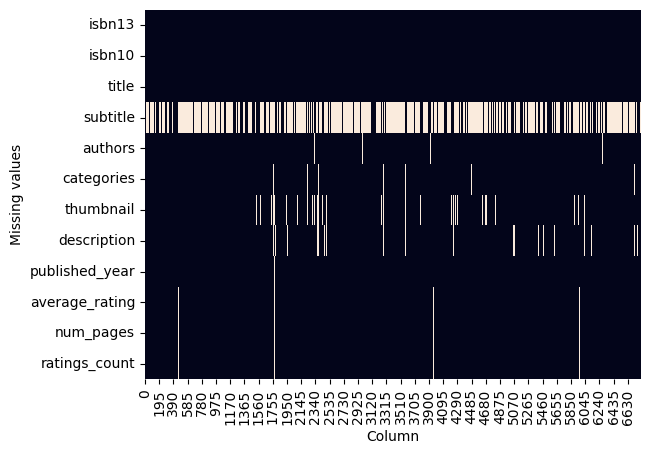

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = plt.axes()
sns.heatmap(books.isna().transpose(), cbar=False, ax=ax)

plt.xlabel("Column")
plt.ylabel("Missing values")
plt.show()

In [8]:
import numpy as np

books["missing_description"]= np.where(books["description"].isna(), 1, 0)
books["age_of_book"] = 2025 - books["published_year"]